In [1]:
import pandas as pd

# 1.0 Read Raw Data
df = pd.read_csv("online_retail.csv")

print(df.head())
print(df.shape)
print(df.columns)

# Result: (541909, 8)
# Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
# 'UnitPrice', 'CustomerID', 'Country'], dtype='object')

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


Result: (541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
'UnitPrice', 'CustomerID', 'Country'], dtype='object')

In [2]:
# 2.0 Clean Data

# Copy
df_clean = df.copy()

# Delete the data without CustomerID (I'll do User Research later)
df_clean = df_clean.dropna(subset=['CustomerID'])

# Delete Return Order which is Quantity <= 0
df_clean = df_clean[df_clean['Quantity']>0]

# Delete abnormal data
df_clean = df_clean[df_clean['UnitPrice']>0]

# Adjust time style
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Create Reveue
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(df_clean.shape)
print(df_clean.head())
print(df.columns)
# Result:(397884, 9)



(397884, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom    15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom    22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
  

In [3]:
# 3.0 Python -> SQL
import sqlite3

# Create database (in memory)
conn = sqlite3.connect(':memory:')

# Create the SQL form
df_clean.to_sql('ecommerce', conn, index=False, if_exists='replace')


# Test
# query = """
# SELECT * FROM ecommerce
# LIMIT 5
# """

397884

In [4]:
# 4.0 Query(1)
# Find the total_revenue for every month
query = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    SUM(Revenue) AS total_revenue
FROM ecommerce
GROUP BY month
ORDER BY month
"""

# Print Top 10
monthly_revenue = pd.read_sql(query, conn)
print(monthly_revenue.head(10))

     month  total_revenue
0  2010-12     572713.890
1  2011-01     569445.040
2  2011-02     447137.350
3  2011-03     595500.760
4  2011-04     469200.361
5  2011-05     678594.560
6  2011-06     661213.690
7  2011-07     600091.011
8  2011-08     645343.900
9  2011-09     952838.382


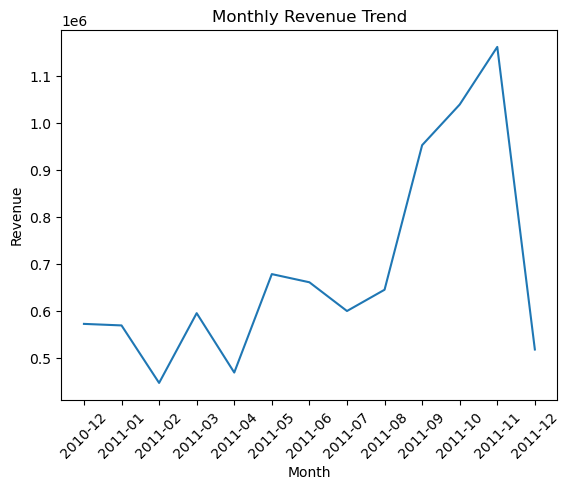

In [5]:
# Data Visulization
import matplotlib.pyplot as plt

plt.plot(monthly_revenue['month'], monthly_revenue['total_revenue'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [6]:
# 5.0 RFM Customer Sementation
# to identify the high-valued customers, the missing customers and the potential customers

query = """
WITH rfm AS (
    SELECT 
        CustomerID,
        MAX(InvoiceDate) AS last_purchase,
        COUNT(DISTINCT InvoiceNo) AS frequency,
        SUM(Revenue) AS monetary
    FROM ecommerce
    GROUP BY CustomerID
)

SELECT *
FROM rfm
LIMIT 10
"""

rfm = pd.read_sql(query, conn)
print(rfm.head())

   CustomerID        last_purchase  frequency  monetary
0     12346.0  2011-01-18 10:01:00          1  77183.60
1     12347.0  2011-12-07 15:52:00          7   4310.00
2     12348.0  2011-09-25 13:13:00          4   1797.24
3     12349.0  2011-11-21 09:51:00          1   1757.55
4     12350.0  2011-02-02 16:01:00          1    334.40


In [7]:
query = """
WITH rfm AS (
    SELECT 
        CustomerID,
        MAX(InvoiceDate) AS last_purchase,
        COUNT(DISTINCT InvoiceNo) AS frequency,
        SUM(Revenue) AS monetary
    FROM ecommerce
    GROUP BY CustomerID
),

max_date AS (
    SELECT MAX(InvoiceDate) AS max_date FROM ecommerce
)

SELECT 
    r.CustomerID,
    JULIANDAY(m.max_date) - JULIANDAY(r.last_purchase) AS recency,
    r.frequency,
    r.monetary
FROM rfm r, max_date m
"""

rfm = pd.read_sql(query, conn)
print(rfm.head())

   CustomerID     recency  frequency  monetary
0     12346.0  325.117361          1  77183.60
1     12347.0    1.873611          7   4310.00
2     12348.0   74.984028          4   1797.24
3     12349.0   18.124306          1   1757.55
4     12350.0  309.867361          1    334.40


In [9]:
# RFM scoring
rfm['R_score'] = pd.qcut(rfm['recency'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)
print(rfm.head())
print(rfm[['R_score', 'F_score', 'M_score', 'RFM_score']].head())

   CustomerID     recency  frequency  monetary R_score F_score M_score  \
0     12346.0  325.117361          1  77183.60       1       1       5   
1     12347.0    1.873611          7   4310.00       5       5       5   
2     12348.0   74.984028          4   1797.24       2       4       4   
3     12349.0   18.124306          1   1757.55       4       1       4   
4     12350.0  309.867361          1    334.40       1       1       2   

  RFM_score  
0       115  
1       555  
2       244  
3       414  
4       112  
  R_score F_score M_score RFM_score
0       1       1       5       115
1       5       5       5       555
2       2       4       4       244
3       4       1       4       414
4       1       1       2       112


In [10]:
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'VIP'
    elif r >= 3 and f >= 4:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Churn Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm[['CustomerID', 'recency', 'frequency', 'monetary', 'RFM_score', 'Segment']].head(10))
print(rfm['Segment'].value_counts())

   CustomerID     recency  frequency  monetary RFM_score             Segment
0     12346.0  325.117361          1  77183.60       115          Churn Risk
1     12347.0    1.873611          7   4310.00       555                 VIP
2     12348.0   74.984028          4   1797.24       244             At Risk
3     12349.0   18.124306          1   1757.55       414  Potential Loyalist
4     12350.0  309.867361          1    334.40       112          Churn Risk
5     12352.0   35.925694          8   2506.04       355               Loyal
6     12353.0  203.793750          1     89.00       111          Churn Risk
7     12354.0  231.985417          1   1079.40       114          Churn Risk
8     12355.0  213.959028          1    459.40       112          Churn Risk
9     12356.0   22.173611          3   2811.43       435             Regular
Segment
Churn Risk            1073
VIP                    948
Regular                846
At Risk                662
Loyal                  501
Potential 

In [11]:
segment_summary = rfm.groupby('Segment').agg(
    customer_count=('CustomerID', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).reset_index()

segment_summary = segment_summary.sort_values(by='avg_monetary', ascending=False)

print(segment_summary)

              Segment  customer_count  avg_recency  avg_frequency  \
5                 VIP             948    12.053934      11.148734   
2               Loyal             501    36.817028       5.145709   
0             At Risk             662   150.049097       3.413897   
4             Regular             846    38.510429       1.842790   
1          Churn Risk            1073   216.325718       1.101584   
3  Potential Loyalist             308    17.557316       1.246753   

   avg_monetary  
5   6069.311635  
2   1849.428166  
0   1250.786965  
4    877.084409  
1    489.108455  
3    442.497435  


In [12]:
monthly_revenue.to_csv("monthly_revenue.csv", index=False)
rfm.to_csv("rfm_customer_segments.csv", index=False)
segment_summary.to_csv("segment_summary.csv", index=False)

product_performance = df_clean.groupby('Description').agg(
    total_quantity=('Quantity', 'sum'),
    total_revenue=('Revenue', 'sum')
).reset_index()

product_performance = product_performance.sort_values(by='total_revenue', ascending=False).head(20)

print(product_performance.head())
product_performance.to_csv("top_products.csv", index=False)

                             Description  total_quantity  total_revenue
2319         PAPER CRAFT , LITTLE BIRDIE           80995      168469.60
2767            REGENCY CAKESTAND 3 TIER           12402      142592.95
3698  WHITE HANGING HEART T-LIGHT HOLDER           36725      100448.15
1762             JUMBO BAG RED RETROSPOT           46181       85220.78
1992      MEDIUM CERAMIC TOP STORAGE JAR           77916       81416.73
